In [2]:
import matplotlib 
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# LSN EXERCISES 02
## Monte Carlo integrals and random walks

Gabriele Borroni (14768A)

---

## 2.1: Monte Carlo integration

Suppose to have to evaluate an integral, and to rewrite it first as:
$$
I=\int_a^b p(x)g(x)dx
$$

where p(x) is a PDF ($\int p(x)dx=1, p(x)\geq 0 \forall x \in \mathbb{R}$).
If p(x) is a uniform distribution, then:
$$
I=\frac{1}{b-a}\int_a^bg(x)dx
$$
Which is the mean (integral) value of g(x) in the interval [a,b]. It follows that,
being $x_i$ a uniform random number, the quantity:
$$
G_N=\frac{1}{N}\sum_{i=1}^Ng(x_i)
$$
is an approximator of the integral, as $N\to\infty$. A way to use Monte Carlo to evaluate integrals is by sampling uniform random numbers and computing $G_N$ for a large number of samples. The main advantage in using Monte Carlo approaches to calculate integrals is that the **error scales as $\propto \frac{1}{\sqrt{N}}$, no matter the dimensionality of the integration space**.

In the first part of the exercise, this method has been implemented to evaluate:
$$
I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1
$$
by sampling 10000 random numbers, divided in 100 blocks. 
Results are shown below.



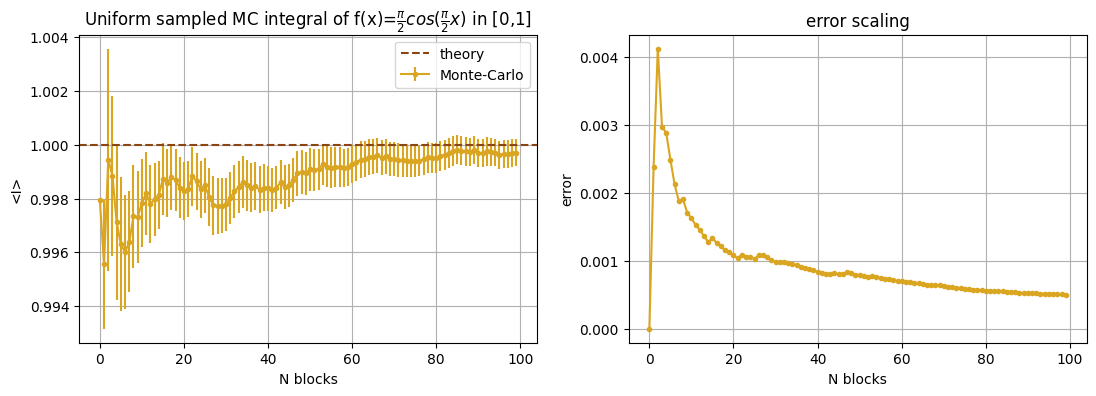

In [3]:

def plot_data_err(ax, x,y, ylabel, title, errorbar=False, err=None, label=None):
    if errorbar is True:
        ax.errorbar(x,y,yerr=err, fmt='-o', ms=3, color='goldenrod',label=label)
    else:
        ax.plot(x,y, '-o',  ms=3, color='goldenrod')
    ax.set_xlabel("N blocks")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True)
data=np.loadtxt("2.1/OUTPUT/UniformMC.dat")
I=data[:,1]
err=data[:,2]
N=data.shape[0]
x=np.arange(N)
fig, ax=plt.subplots(1,2, figsize=(13,4))
plot_data_err(ax[0], x, I, "<I>",r"Uniform sampled MC integral of f(x)=$ \frac{\pi}{2}cos(\frac{\pi}{2}x) $ in [0,1]", True, err, "Monte-Carlo")
plot_data_err(ax[1],x, err, "error", "error scaling")
ax[0].axhline(y=1, color='saddlebrown', ls='--', label='theory')
ax[0].legend()
plt.show()


## Boosting Monte Carlo integration with importance sampling

Monte Carlo is like throwing darts blindfolded and hoping some land on the target. Importance sampling doesn't remove the blindfold, but at least it points you in the target's direction, so that you waste fewer darts.

The idea is to evaluate:
$$
I=\int_a^b p(x)g(x)dx
$$

using an appropriate probability distribution d to sample from, which can be introduced by rewriting the integral as
$$
I=\int_a^b \frac{g(x)p(x)}{d(x)}d(x)dx
$$

So that the estimator now becomes:
$$
G_N = \frac{1}{N} \sum_{i=1}^N \frac{g(x_i)p(x_i)}{d(x_i)} \qquad \text{with } x_i \sim d(x)
$$

It's possible to show that **the closer the sampling distribution $d(x)$ is to the shape of the integrand $g(x)p(x)$, the lower the variance of the estimator**, for a fixed number of samples.

The same integral as before has been evaluated by sampling from:
$$
d(x)=2(1-x)
$$
which is normalized and always positive in the considered integration interval, defining a PDF. The choice behind this distribution relies in two main factors:

1. same behaviour of the integrand in x=0 (maximum) and x=1 (g(1)=p(1)=0).


2. both p(x) and the integrand are monotonically decreasing functions in [0,1].

The code implements this calculation basically in the same way as before, but sampling from p(x) (using the inverse of the cumulative function) instead of uniform distribution.

This integral in particular was easy to calculate by hand, so it was possible to sample from $p(x)=g(x)$, which returns the exact integral with zero variance. This result has also been plotted to show the most extreme (and useless) use of importance sampling, and as a fancy way to show the theoretical result.

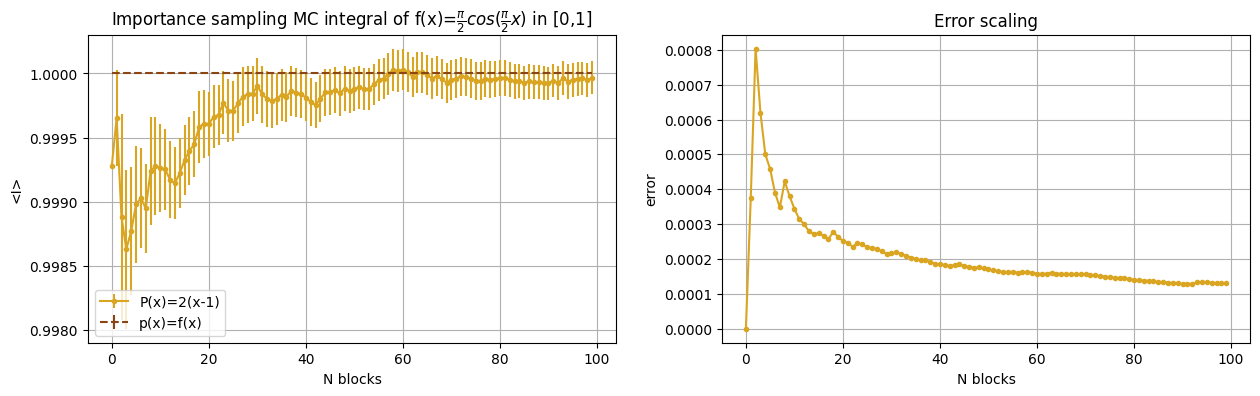

In [4]:
data1=np.loadtxt("2.1/OUTPUT/MCBestIS.dat")
I1=data1[:,1]
err1=data1[:,2]
data2=np.loadtxt("2.1/OUTPUT/MCLinearIS.dat")
I2=data2[:,1]
err2=data2[:,2]
N=data1.shape[0]
x=np.arange(N)
fig, ax=plt.subplots(1,2, figsize=(15,4))
plot_data_err(ax[0], x, I2, "<I>",r"Importance sampling MC integral of f(x)=$ \frac{\pi}{2}cos(\frac{\pi}{2}x) $ in [0,1]", True, err2, "P(x)=2(x-1)")
plot_data_err(ax[1],x, err2, "error", "Error scaling", False )
ax[0].errorbar(x,I1,yerr=err1, ls='--', color='saddlebrown',label="p(x)=f(x)")
ax[0].legend()

plt.show()

---

# Exercise 2.2: random walks

A random walk is made by an agent which at any time $t$ can take a single step in any direction.

Mathematically, it is modelled as a **Markov chain**, namely a process which has no memory: every step taken at time $t_i$ depends only on the positionn at time $t_{i-1}$. A random walk can be implemented either on a **discrete lattice**, with a finite number of direction available for each step, or in a **continuous space**, with infinitely many possible directions to choose from.

In this case, the random walk follows the **diffusion equation**:
$$
\frac{\partial \rho(x,t)}{\partial t} = D \, \frac{\partial^2 \rho(x,t)}{\partial x^2}
$$

where $\rho(x,t)$ represents the probability of finding the agent in the position x at time t. 

This connection is what makes the random walk a powerful tool to model real diffusive phenomena such as: heat diffusion, molecular progation in a fluid, brownian motion or even stock markets dinamics.

in the code, a 3D version of random walk in both the cases of discrete and continuum space have been implemented in the class RandomWalk, in RandomWalk.cpp. Below there is a demonstration of what it looks like.

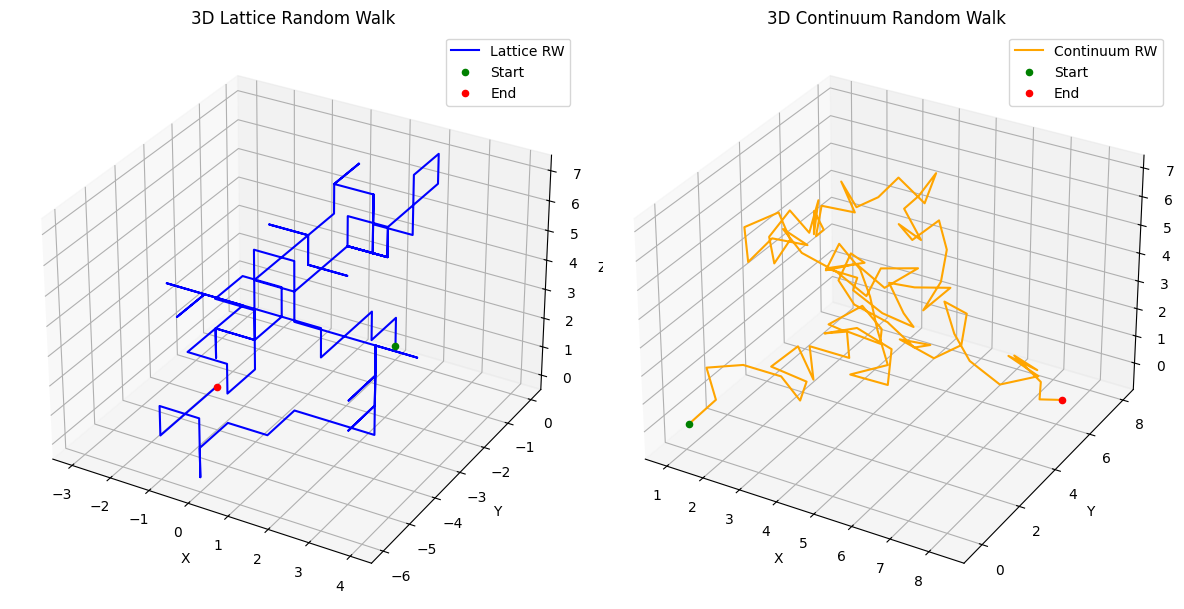

In [5]:
# first Random Walk (lattice) 
data1 = np.loadtxt("2.2/OUTPUT/completeRW_lattice.dat")
x1, y1, z1 = data1[:, 0], data1[:, 1], data1[:, 2]
# Second Random Walk (continuum) 
data2 = np.loadtxt("2.2/OUTPUT/completeRW_continuum.dat")
x2, y2, z2 = data2[:, 0], data2[:, 1], data2[:, 2]

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(x1, y1, z1, color='blue', label='Lattice RW')
ax1.scatter(x1[0], y1[0], z1[0], color='green', label='Start')
ax1.scatter(x1[-1], y1[-1], z1[-1], color='red', label='End')
ax1.set_title('3D Lattice Random Walk')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.legend()
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(x2, y2, z2, color='orange', label='Continuum RW')
ax2.scatter(x2[0], y2[0], z2[0], color='green', label='Start')
ax2.scatter(x2[-1], y2[-1], z2[-1], color='red', label='End')
ax2.set_title('3D Continuum Random Walk')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.legend()
plt.tight_layout()
plt.show()


## Average mean square displacement

In random walks, an interesting quanitity is the AMSD, which is the average distance from the origin reached after a fixed number of steps in funcion of the number of walkers N $\langle|\vec{r}_N|^2 \rangle$.

Theoretically, the AMSD for a 3D random walk follows a power law: it scales as $f(N)=\sqrt{N}$.

In the first part, this calculation has been implemented for the discrete lattice random walk, by making $10^4$ agents walk 100 steps each, and dividing the results in 100 blocks. At every time step, each walker can take a step of length $a=1$ in a random discrete-direction $(x,y,z)$. 

The results shown below clearly demonstrate that this random walk follows the power law mentioned before, which demonstrates a **diffusive behaviour**: the distance from the origin $\langle r^2 \rangle$ grows linearly with N, and so $\sqrt{\langle r^2 \rangle}$ grows as $\sqrt{N}$ .

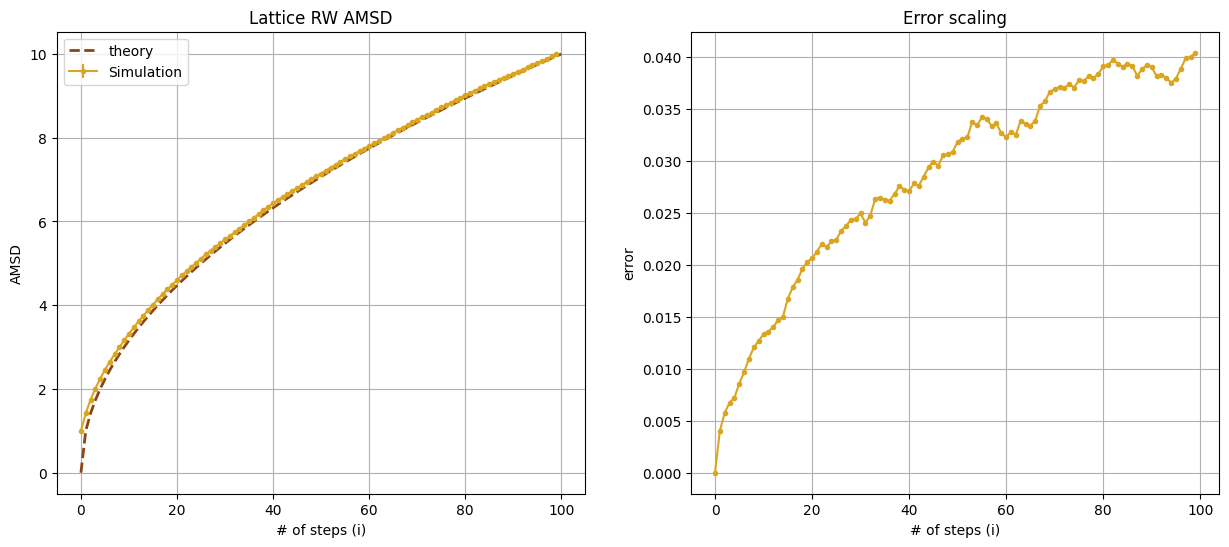

In [6]:
data_lattice=np.loadtxt("2.2/OUTPUT/LatticeAMSD.dat")
yl=data_lattice[:,1]
erryl=data_lattice[:,2]
N=data_lattice.shape[0]
x=np.arange(N)
x_theory=np.linspace(0,N, 100)
k=1
y_theory=k*np.sqrt(x_theory)
fig, ax =plt.subplots(1,2, figsize=(15,6))
plot_data_err(ax[0], x,yl, 'AMSD', 'Lattice RW AMSD', True, err=erryl, label='Simulation')
ax[0].plot(x_theory, y_theory, color="saddlebrown",lw=2, ls='--', label="theory")
ax[0].set_xlabel('# of steps (i)')
ax[0].set_ylabel('AMSD')
ax[0].grid(True)
ax[0].legend()
plot_data_err(ax[1], x,erryl, 'error', 'Error scaling', False)
ax[1].set_xlabel('# of steps (i)')
ax[1].grid(True)
plt.show()

In the second part, the same calculation has been implemented in the continuum case. The code works in the same way, the only difference relies in the direction sampling: a random point on the sphere is sampled (with uniform probability on all the sphere) by drawing two angles in spherical coordinates (r=1):

1. a random uniform $\phi \in [0,2\pi]$

2. a random $\theta$, sampled from $p(\theta)=\frac{1}{2}\sin(\theta)$ with the inverse of the cumulative method


same considerations on the diffusive process hold for this case.

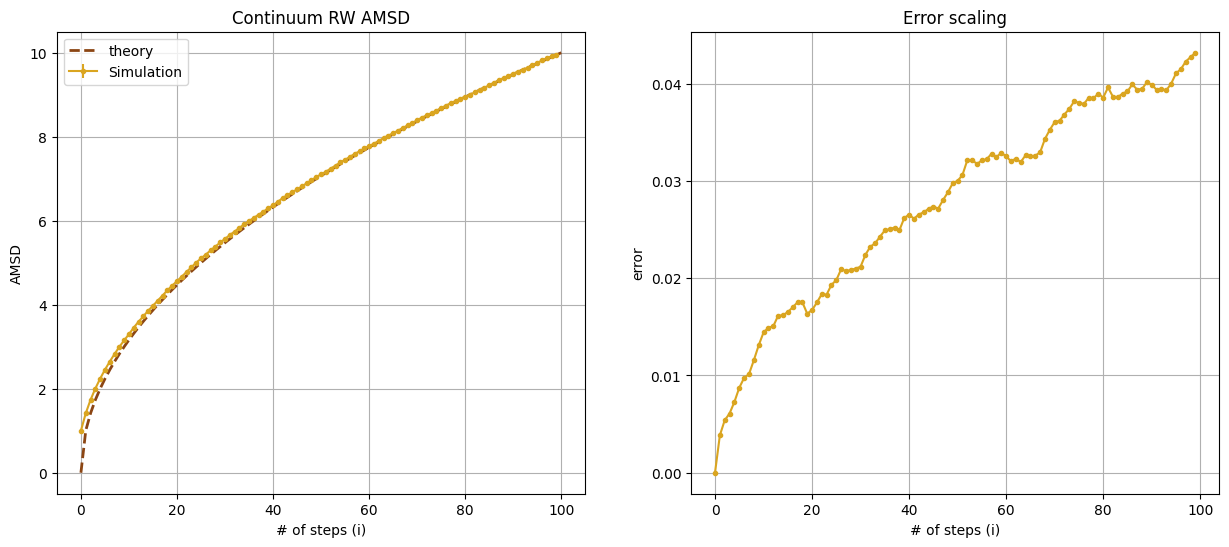

In [7]:
data_lattice=np.loadtxt("2.2/OUTPUT/ContinuumAMSD.dat")
yl=data_lattice[:,1]
erryl=data_lattice[:,2]
N=data_lattice.shape[0]
x=np.arange(N)
x_theory=np.linspace(0,N, 100)
k=1
y_theory=k*np.sqrt(x_theory)
fig, ax =plt.subplots(1,2, figsize=(15,6))
plot_data_err(ax[0], x,yl, 'AMSD', 'Continuum RW AMSD', True, err=erryl, label='Simulation')
ax[0].plot(x_theory, y_theory, color="saddlebrown",lw=2, ls='--', label="theory")
ax[0].set_xlabel('# of steps (i)')
ax[0].set_ylabel('AMSD')
ax[0].grid(True)
ax[0].legend()
plot_data_err(ax[1], x,erryl, 'error', 'Error scaling', False)
ax[1].set_xlabel('# of steps (i)')
ax[1].grid(True)
plt.show()